# Analiza zdrowia publicznego i czynnikow socjoekonomicznych w USA (2011-2023)

Celem analizy jest zbadanie zaleznosci miedzy wskaznikami zdrowotnymi (otylosc, aktywnosc fizyczna) a czynnikami spoleczno-ekonomicznymi na poziomie stanow USA. Dane pochodza z czterech zrodel:
- **CDC BRFSS** (`health_data_clean.csv`) - wskazniki zdrowotne, 50 stanow + National, 2011-2024
- **ACS Census** (`census_acs_stany_2011_2023.csv`) - zmienne socjoekonomiczne per stan, 10 lat
- **CBP** (`cbp_businesses.csv`) - liczba silowni i sklepow alkoholowych per stan
- **NOAA** (`pogoda_stany_2011_2023_niepelne.csv`) - miesieczne dane pogodowe per stan

## 1. Wczytanie danych i przygotowanie

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from sklearn.metrics import silhouette_score
from scipy.stats import spearmanr
import warnings

warnings.simplefilter(action="ignore", category=FutureWarning)

sns.set_theme(style="whitegrid", font_scale=1.05)
PALETTE = {
    "Northeast": "#4C72B0",
    "Midwest": "#DD8452",
    "South": "#55A868",
    "West": "#C44E52",
}

In [2]:
health_raw = pd.read_csv("./data/health_data_clean.csv")
census_raw = pd.read_csv("./data/census_acs_stany_2011_2023.csv")
biz_raw = pd.read_csv("./data/cbp_businesses.csv")
# weather_raw = pd.read_csv('./data/pogoda_stany_2011_2023_niepelne.csv', on_bad_lines='skip')
weather_raw = pd.read_csv("./data/pogoda_stany_naprawione_2011_2023.csv")
div_raw = pd.read_csv("./data/usa_divisions1.csv")

In [3]:
# health: tylko stratyfikacja 'Total', pivot do szerokiego formatu
QUESTIONS = {
    "Q036": "Obesity",
    "Q037": "Overweight",
    "Q047": "NoActivity",
    "Q045": "HighActivity",
    "Q043": "ModActivity",
    "Q046": "MuscleActivity",
    "Q018": "LowFruits",
    "Q019": "LowVeggies",
}

health_total = health_raw[
    (health_raw["StratificationCategory"] == "Total")
    & (health_raw["QuestionID"].isin(QUESTIONS))
].copy()
health_total["MetricName"] = health_total["QuestionID"].map(QUESTIONS)

health_pivot = health_total.pivot_table(
    index=["Year", "LocationDesc", "LocationAbbr"],
    columns="MetricName",
    values="Value",
).reset_index()

In [4]:
health_pivot.isna().sum()

MetricName
Year                0
LocationDesc        0
LocationAbbr        0
HighActivity      414
LowFruits         569
LowVeggies        569
ModActivity       414
MuscleActivity    414
NoActivity          0
Obesity             0
Overweight          0
dtype: int64

In [5]:
# census: kolumna pct_wyksztalcenie_wyzsze przed 2019 zawiera wartosci bezwzgledne,
# od 2019 poprawny procent. Zerujemy lata przed 2019.
census = census_raw.copy()
census.loc[census["rok"] < 2019, "pct_wyksztalcenie_wyzsze"] = np.nan
census = census.rename(columns={"rok": "Year", "stan_nazwa": "LocationDesc"})

# pogoda: agregacja do poziomu rocznego per stan
weather_annual = (
    weather_raw.groupby(["stan_nazwa", "rok"])
    .agg(
        avg_temp=("TAVG_mean", "mean"),  # średnia temperatura
        avg_prcp=(
            "PRCP_mean",
            "sum",
        ),  # roczna suma średnich miesięcznych opadów - działa bardziej jako wskaźnik niż wartość
    )
    .reset_index()
    .rename(columns={"stan_nazwa": "LocationDesc", "rok": "Year"})
)


# podzial na regiony/dywizje
div_map = div_raw.set_index("State")[["Region", "Division"]].to_dict("index")

# laczenie wszystkich zrodel
df = health_pivot.merge(census, on=["Year", "LocationDesc"], how="inner")
df = df.merge(weather_annual, on=["Year", "LocationDesc"], how="left")
df = df.merge(
    biz_raw.rename(columns={"year": "Year", "state_abbr": "LocationAbbr"})[
        ["Year", "LocationAbbr", "fitness_centers_estab", "liquor_stores_estab"]
    ],
    on=["Year", "LocationAbbr"],
    how="left",
)

df["Region"] = df["LocationDesc"].map(lambda x: div_map.get(x, {}).get("Region"))
df["Division"] = df["LocationDesc"].map(lambda x: div_map.get(x, {}).get("Division"))
df["fitness_per_100k"] = df["fitness_centers_estab"] / (df["populacja_total"] / 1e5)

# panel bez 'National'
df = df[df["LocationDesc"] != "National"].reset_index(drop=True)

df = df.drop(columns="stan_fips")

print(f"Rozmiar panelu: {df.shape[0]} wierszy x {df.shape[1]} kolumn")
print(f'Lata: {sorted(int(year) for year in df["Year"].unique())}')
print(f'Stany: {df["LocationDesc"].nunique()}')

Rozmiar panelu: 496 wierszy x 39 kolumn
Lata: [2013, 2014, 2015, 2016, 2017, 2018, 2019, 2021, 2022, 2023]
Stany: 50


In [6]:
df.head()

,Year,LocationDesc,LocationAbbr,HighActivity,LowFruits,LowVeggies,ModActivity,MuscleActivity,NoActivity,Obesity,...,liczba_gospodarstw_domowych,pct_gospodarstwa_z_dziecmi,pct_dostep_internet,avg_temp,avg_prcp,fitness_centers_estab,liquor_stores_estab,Region,Division,fitness_per_100k
0,2013,Alabama,AL,27.3,NaN,NaN,45.4,24.9,31.5,32.4,...,1822439,NaN,63.5,16.893924,1706.782034,357,359,South,East South Central,7.385613
1,2013,Alaska,AK,36.4,NaN,NaN,55.3,36.0,22.3,28.4,...,246015,NaN,79.0,-0.141466,1120.644076,74,100,West,Pacific,10.066219
2,2013,Arizona,AZ,34.0,NaN,NaN,51.9,31.0,25.2,26.8,...,2400809,NaN,73.9,14.633406,318.788355,489,200,West,Mountain,7.379323
3,2013,Arkansas,AR,25.6,NaN,NaN,41.2,22.3,34.4,34.6,...,1125899,NaN,60.9,15.291090,1346.789032,222,335,South,West South Central,7.501589
4,2013,California,CA,36.0,NaN,NaN,56.3,33.2,21.4,24.1,...,12650592,NaN,77.9,14.749812,202.727968,3322,3815,West,Pacific,8.666271


In [7]:
df.columns

Index(['Year', 'LocationDesc', 'LocationAbbr', 'HighActivity', 'LowFruits',
       'LowVeggies', 'ModActivity', 'MuscleActivity', 'NoActivity', 'Obesity',
       'Overweight', 'populacja_total', 'pct_ponizej_18lat',
       'pct_powyzej_65lat', 'mediana_dochodu_gosp_dom', 'pct_ubóstwo',
       'pct_zatrudnieni', 'pct_bezrobocie', 'pct_dojazd_samochod',
       'pct_dojazd_carpool', 'pct_dojazd_transport_pub', 'pct_dojazd_pieszo',
       'pct_praca_z_domu', 'sredni_czas_dojazdu_min',
       'pct_wyksztalcenie_srednie', 'pct_wyksztalcenie_wyzsze',
       'pct_bez_ubezpieczenia', 'liczba_jednostek_mieszkalnych',
       'pct_mieszkania_wynajmowane', 'liczba_gospodarstw_domowych',
       'pct_gospodarstwa_z_dziecmi', 'pct_dostep_internet', 'avg_temp',
       'avg_prcp', 'fitness_centers_estab', 'liquor_stores_estab', 'Region',
       'Division', 'fitness_per_100k'],
      dtype='str')

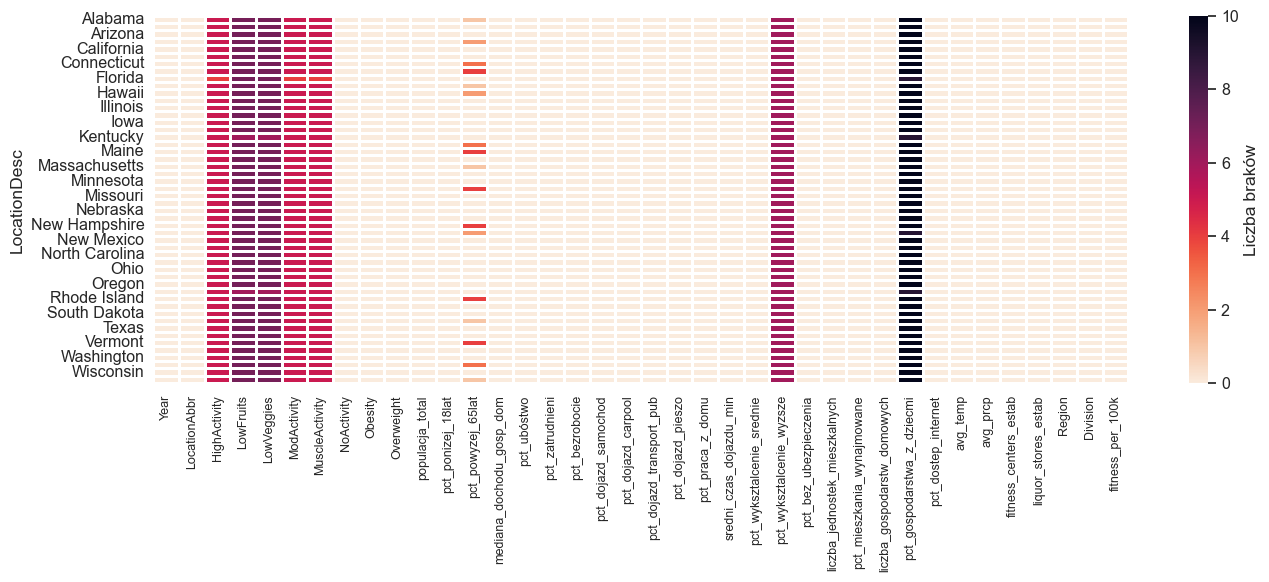

In [8]:
fig, ax = plt.subplots(figsize=(14, 6))
heat_data = df.groupby(["LocationDesc"]).apply(lambda x: x.isna().sum())
sns.heatmap(
    heat_data,
    cmap="rocket_r",
    linewidths=0.8,
    linecolor="white",
    ax=ax,
    cbar_kws={"label": "Liczba braków"},
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="center", fontsize=9)
ax.tick_params(axis="x", which="major", length=5, width=0.8)
ax.tick_params(axis="y", which="major", length=3, width=0.6)
plt.tight_layout()
plt.show()

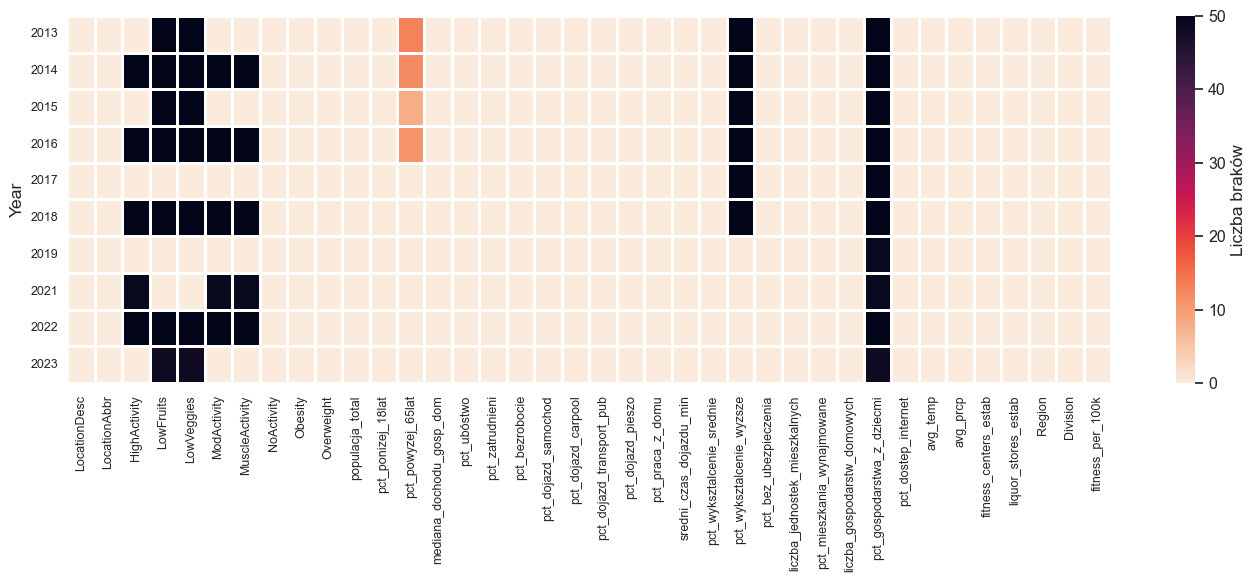

In [9]:
fig, ax = plt.subplots(figsize=(14, 6))
heat_data = df.groupby(["Year"]).apply(lambda x: x.isna().sum())
sns.heatmap(
    heat_data,
    cmap="rocket_r",
    linewidths=0.8,
    linecolor="white",
    ax=ax,
    cbar_kws={"label": "Liczba braków"},
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="center", fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, va="center", fontsize=9)
ax.tick_params(axis="x", which="major", length=5, width=0.8)
ax.tick_params(axis="y", which="major", length=3, width=0.6)
plt.tight_layout()
plt.show()

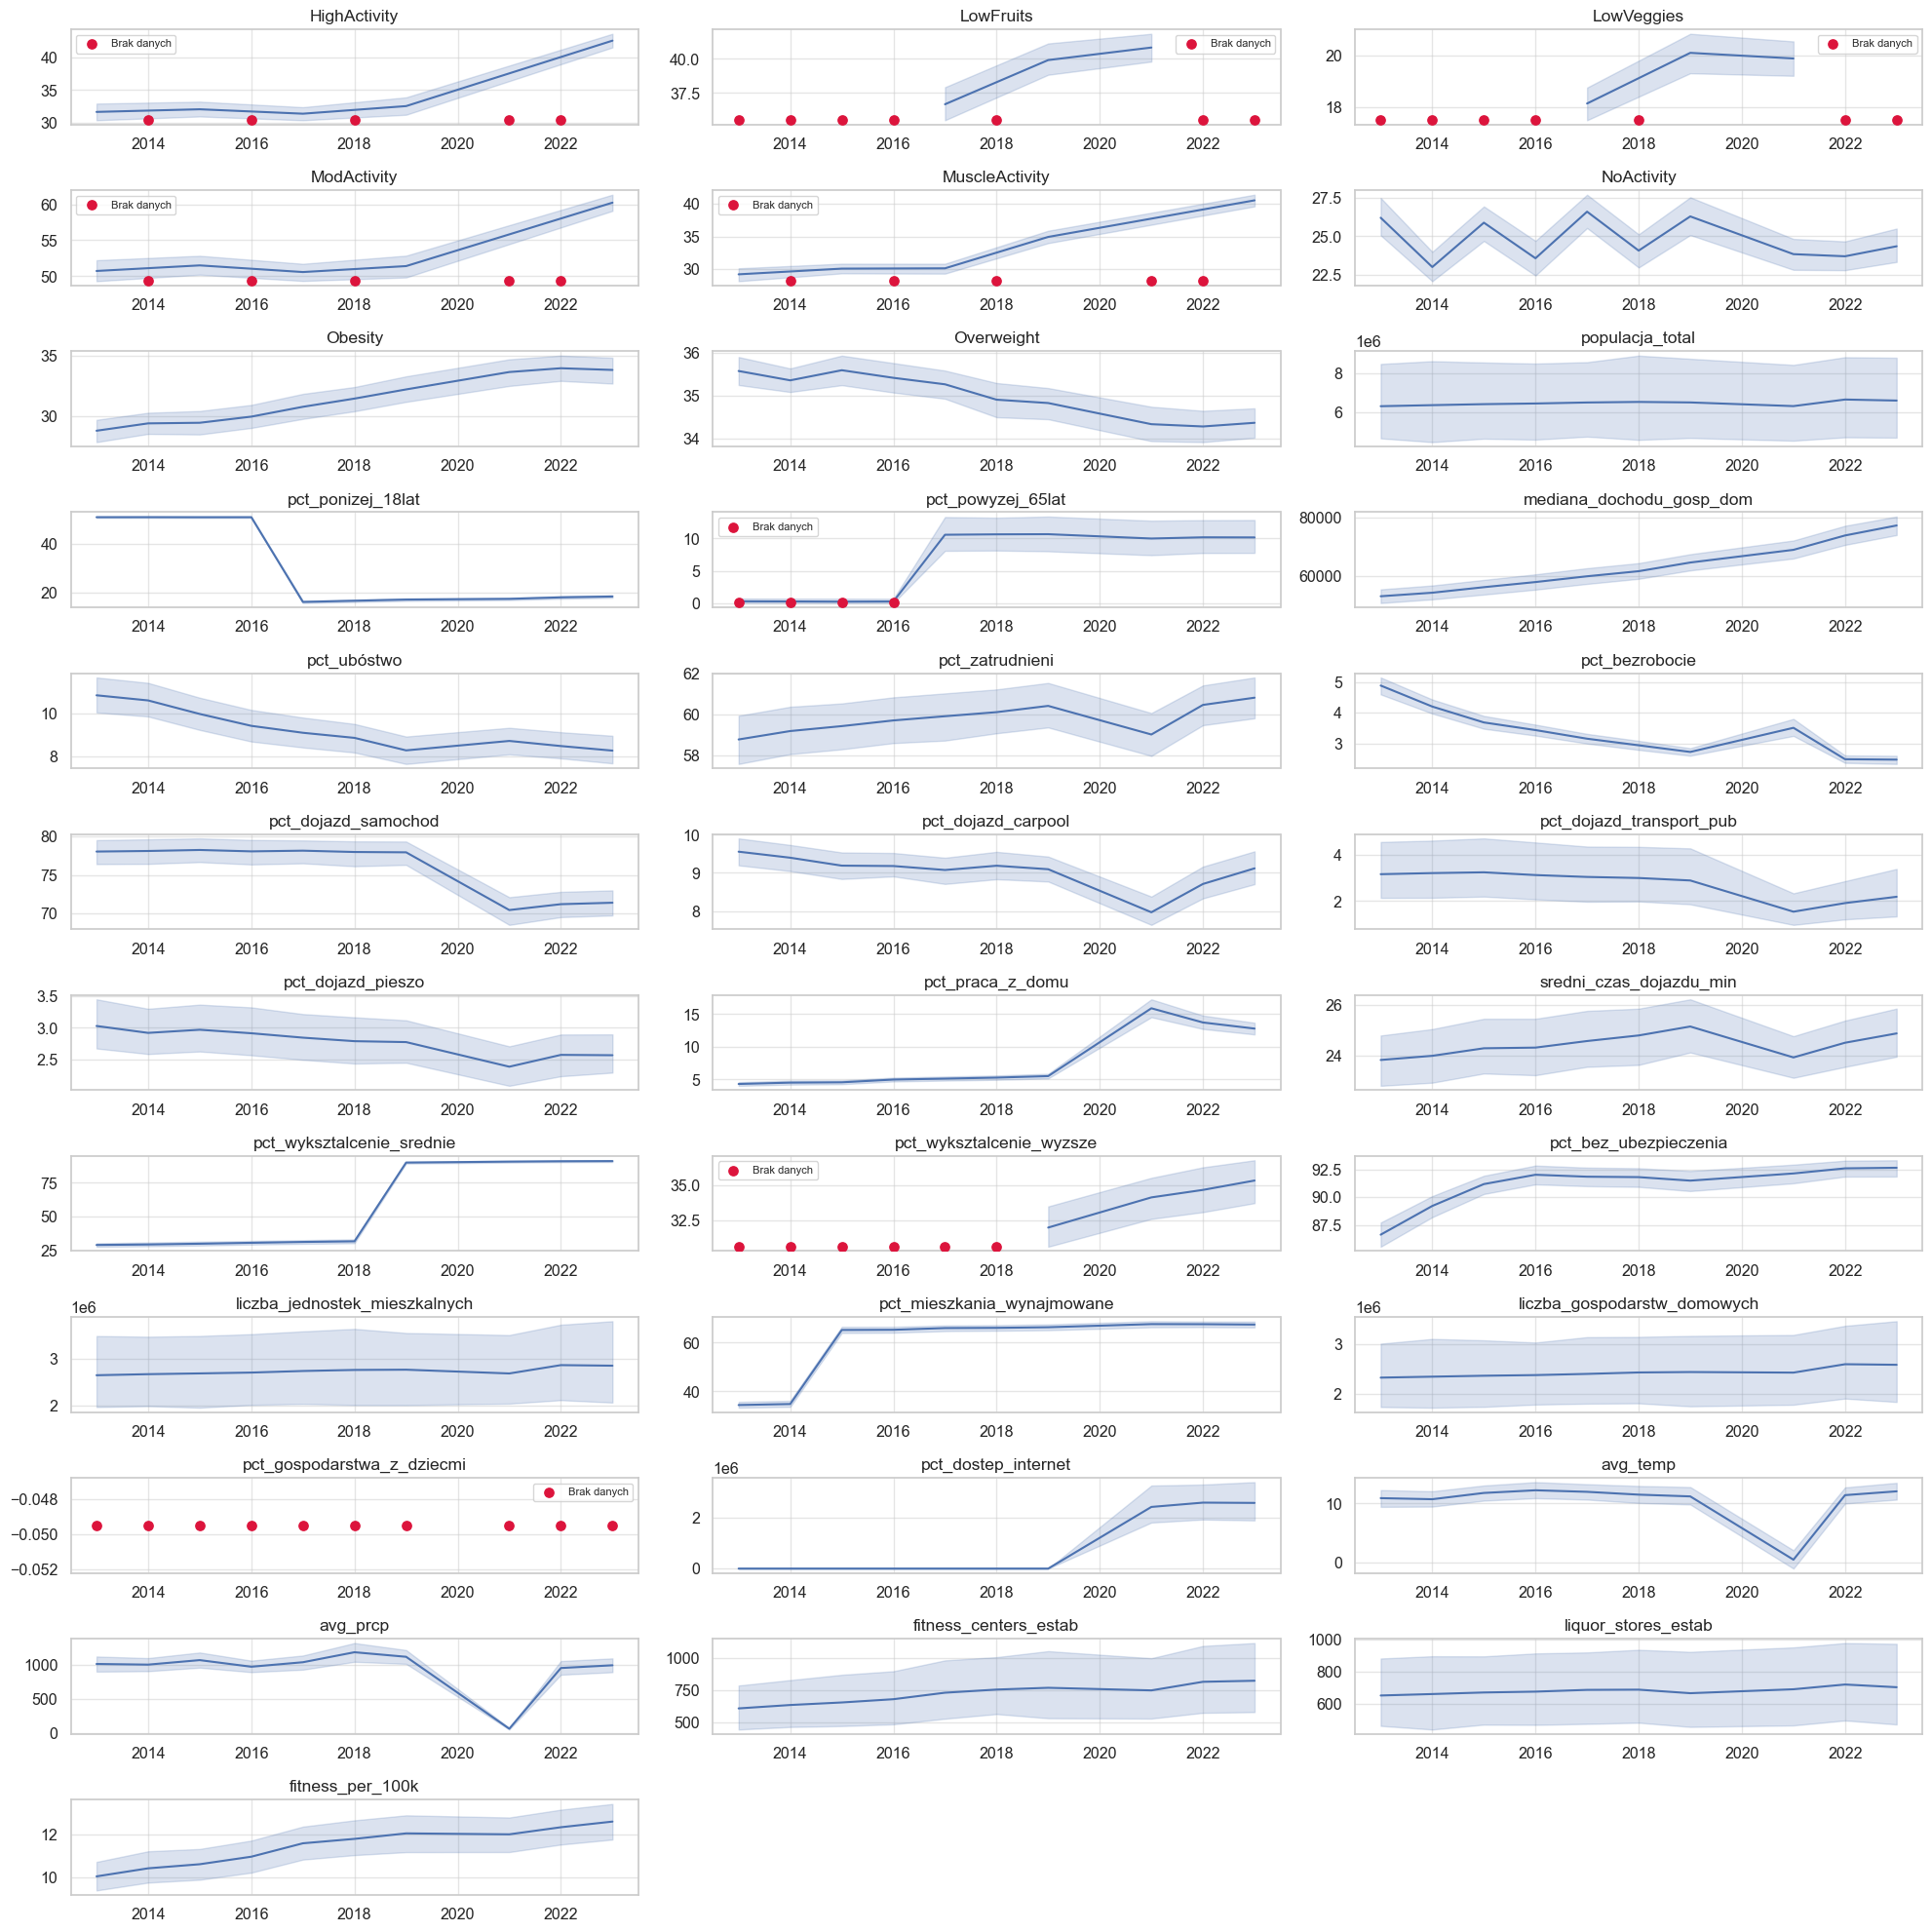

In [10]:
vars = df.drop(columns=["Region", "Division"]).columns[3:]
n = len(vars)
cols = 3
rows = int(np.ceil(n / cols))

fig, axes = plt.subplots(rows, cols, figsize=(20, 20))
axes = axes.flatten()

for i, col in enumerate(vars):
    ax = axes[i]
    sns.lineplot(data=df, x="Year", y=col, ax=ax)

    missing_years = df.loc[df[col].isna(), "Year"].dropna().unique()
    if len(missing_years) > 0:
        y0, y1 = ax.get_ylim()
        y_missing = y0 + 0.05 * (y1 - y0)
        ax.scatter(
            missing_years,
            [y_missing] * len(missing_years),
            color="crimson",
            marker="o",
            s=45,
            label="Brak danych",
            zorder=5,
        )
        ax.legend(fontsize=8, loc="best")

    ax.set_title(col)
    ax.set_ylabel("")
    ax.set_xlabel("")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [11]:
# usredniony profil per stan (do PCA i klastrowania)
CLUSTER_COLS = [
    "Obesity",
    "NoActivity",
    "HighActivity",
    "mediana_dochodu_gosp_dom",
    "pct_ubóstwo",
    "pct_bezrobocie",
    "pct_wyksztalcenie_wyzsze",
    "pct_bez_ubezpieczenia",
    "pct_dojazd_samochod",
    "pct_praca_z_domu",
    "fitness_per_100k",
    "avg_temp",
]

In [12]:
# # Wersja z samymi danymi z 2023

# df_state = df[df['Year']==2023][["LocationDesc", "LocationAbbr", "Region", "Division"] + CLUSTER_COLS]

# print(f"Stany w zbiorze 2023: {len(df_state)}")
# print(f"Braki w danych: {df_state[CLUSTER_COLS].isna().sum().sum()}")

In [13]:
# Wersja z agregacją do średniej

df_state = (
    df[df["Region"].notna()]
    .groupby(["LocationDesc", "LocationAbbr", "Region", "Division"])[CLUSTER_COLS]
    .mean()
    .reset_index()
)

# imputacja brakow mediana z regionu (dotyczy avg_temp - 10 stanow bez danych NOAA)
for col in CLUSTER_COLS:
    if df_state[col].isna().any():
        region_median = df_state.groupby("Region")[col].median()
        df_state[col] = df_state.apply(
            lambda row: region_median[row["Region"]] if pd.isna(row[col]) else row[col],
            axis=1,
        )

print(f"Stany w zbiorze usrednionym: {len(df_state)}")
print(f"Braki po imputacji: {df_state[CLUSTER_COLS].isna().sum().sum()}")

Stany w zbiorze usrednionym: 50
Braki po imputacji: 0


## 2. Statystyki opisowe

In [14]:
DESC_COLS = {
    "Obesity": "otylosc [%]",
    "NoActivity": "brak aktywnosci [%]",
    "HighActivity": "wysoka aktywnosc [%]",
    "mediana_dochodu_gosp_dom": "mediana dochodu [USD]",
    "pct_ubóstwo": "ubostwo [%]",
    "pct_wyksztalcenie_wyzsze": "wyzsze wyksztalcenie [%]",
    "pct_bez_ubezpieczenia": "bez ubezpieczenia [%]",
    "fitness_per_100k": "silownie / 100k mieszk.",
}

desc = df_state[list(DESC_COLS.keys())].describe().T
desc.index = [DESC_COLS[c] for c in desc.index]
desc = desc[["mean", "std", "min", "25%", "50%", "75%", "max"]].round(2)
desc.columns = ["srednia", "std", "min", "Q1", "mediana", "Q3", "max"]
desc

,srednia,std,min,Q1,mediana,Q3,max
otylosc [%],31.31,3.59,22.95,28.75,31.43,33.66,38.42
brak aktywnosci [%],24.78,3.70,17.36,22.43,24.48,26.71,33.59
wysoka aktywnosc [%],33.95,3.88,25.92,31.14,33.21,36.64,42.22
mediana dochodu [USD],62612.23,10111.99,44966.60,55983.18,60447.40,70248.70,83587.40
ubostwo [%],9.26,2.48,4.76,7.33,8.61,10.78,15.60
wyzsze wyksztalcenie [%],34.01,5.45,23.50,30.91,33.63,37.16,46.50
bez ubezpieczenia [%],91.15,3.00,82.07,89.25,91.41,93.47,97.16
silownie / 100k mieszk.,11.44,2.77,6.10,9.43,11.47,12.84,18.32


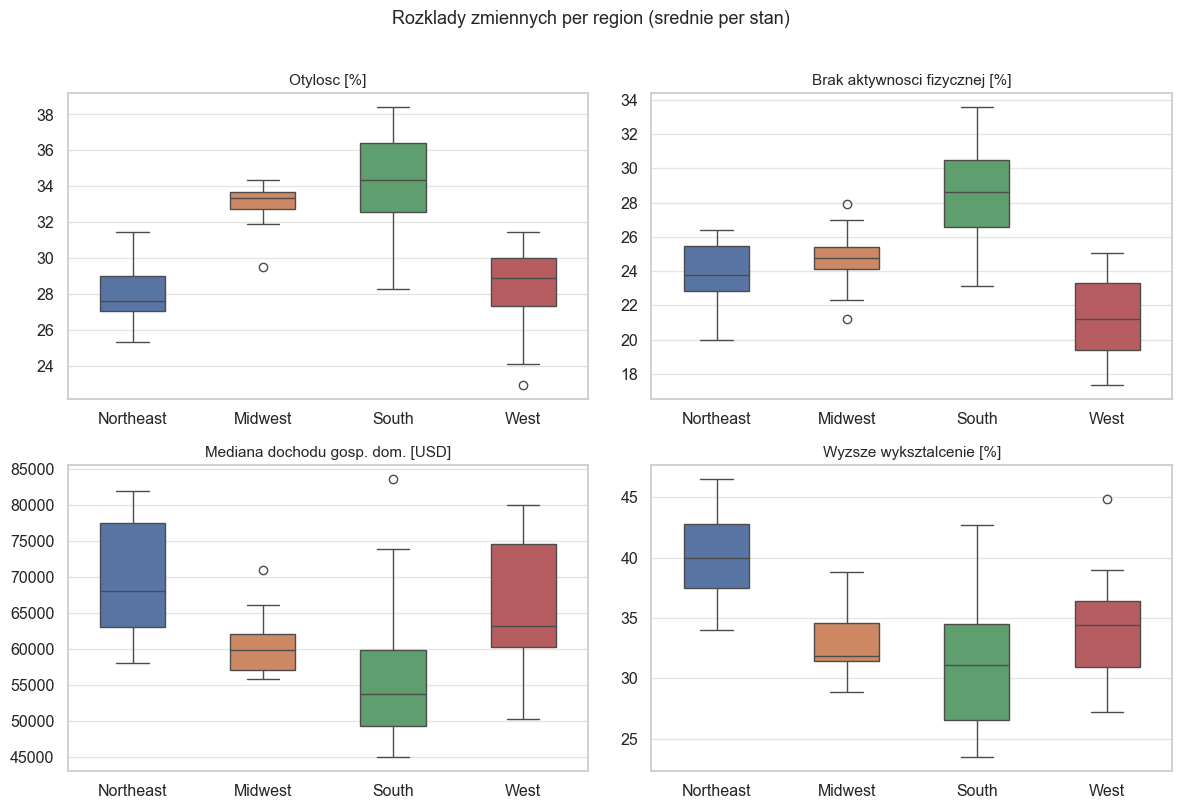

In [15]:
# rozklady kluczowych zmiennych per region

BOXPLOT_VARS = [
    ("Obesity", "Otylosc [%]"),
    ("NoActivity", "Brak aktywnosci fizycznej [%]"),
    ("mediana_dochodu_gosp_dom", "Mediana dochodu gosp. dom. [USD]"),
    ("pct_wyksztalcenie_wyzsze", "Wyzsze wyksztalcenie [%]"),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, (col, label) in zip(axes, BOXPLOT_VARS):
    order = ["Northeast", "Midwest", "South", "West"]
    sns.boxplot(
        data=df_state, x="Region", y=col, order=order, palette=PALETTE, width=0.5, ax=ax
    )
    ax.set_title(label, fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel("")

plt.suptitle("Rozklady zmiennych per region (srednie per stan)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

Poludnie (South) wyroznia sie najwyzsza otyloscią i najwiekszym brakiem aktywnosci fizycznej przy jednoczesnie najnizszych dochodach. Polnocny wschod (Northeast) jest po przeciwnej stronie - wysokie dochody, nizsza otylosc. Zachod (West) i Srodkowy Zachod (Midwest) zajmuja pozycje posrednie.

## 3. Trendy czasowe

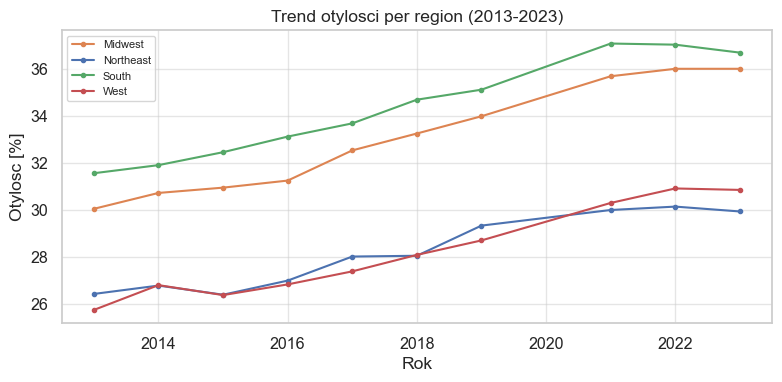

In [16]:
trend_region = (
    df[df["Region"].notna()].groupby(["Year", "Region"])["Obesity"].mean().reset_index()
)

fig, ax = plt.subplots(figsize=(8, 4))

for region, grp in trend_region.groupby("Region"):
    ax.plot(
        grp["Year"],
        grp["Obesity"],
        marker="o",
        markersize=3,
        label=region,
        color=PALETTE[region],
    )

ax.set_title("Trend otylosci per region (2013-2023)")
ax.set_xlabel("Rok")
ax.set_ylabel("Otylosc [%]")
ax.xaxis.set_major_locator(mticker.MultipleLocator(2))
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [17]:
# interaktywny podglad: otylosc per stan w czasie
trend_states = (
    df[df["Region"].notna()]
    .groupby(["Year", "LocationDesc", "LocationAbbr", "Region"])["Obesity"]
    .mean()
    .reset_index()
)

fig = px.line(
    trend_states,
    x="Year",
    y="Obesity",
    color="Region",
    line_group="LocationDesc",
    hover_name="LocationDesc",
    color_discrete_map=PALETTE,
    labels={"Obesity": "Otylosc [%]", "Year": "Rok"},
    title="Otylosc per stan w czasie (2013-2023)",
)
fig.update_traces(opacity=0.55, line_width=1.2)
fig.update_layout(height=450)
fig.show()

We wszystkich regionach obserwujemy wyrany trend wzrostowy otylości - szczegolnie widoczny w latach 2013-2020. Brak aktywnosci fizycznej utrzymuje wzglednie staly poziom z lekkim wzrostem w 2020 (efekt pandemii COVID-19). Wysoka aktywnosc rosnie stopniowo w Northeast i West, natomiast South pozostaje wyranie ponizej pozostalych regionow we wszystkich trzech wskaznikach.

## 4. Macierz korelacji

In [18]:
CLUSTER_COLS

['Obesity',
 'NoActivity',
 'HighActivity',
 'mediana_dochodu_gosp_dom',
 'pct_ubóstwo',
 'pct_bezrobocie',
 'pct_wyksztalcenie_wyzsze',
 'pct_bez_ubezpieczenia',
 'pct_dojazd_samochod',
 'pct_praca_z_domu',
 'fitness_per_100k',
 'avg_temp']

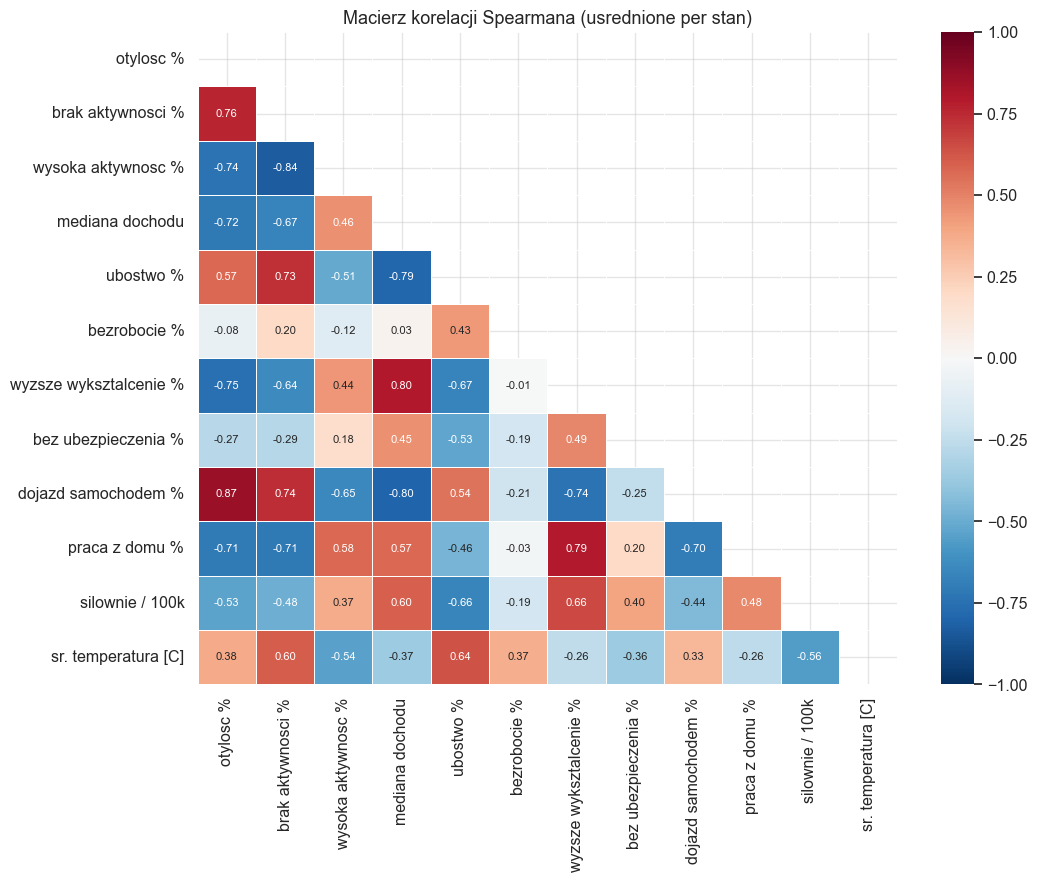

In [19]:
HEATMAP_COLS = {
    "Obesity": "otylosc %",
    "NoActivity": "brak aktywnosci %",
    "HighActivity": "wysoka aktywnosc %",
    "mediana_dochodu_gosp_dom": "mediana dochodu",
    "pct_ubóstwo": "ubostwo %",
    "pct_bezrobocie": "bezrobocie %",
    "pct_wyksztalcenie_wyzsze": "wyzsze wyksztalcenie %",
    "pct_bez_ubezpieczenia": "bez ubezpieczenia %",
    "pct_dojazd_samochod": "dojazd samochodem %",
    "pct_praca_z_domu": "praca z domu %",
    "fitness_per_100k": "silownie / 100k",
    "avg_temp": "sr. temperatura [C]",
}

corr_data = df_state[list(HEATMAP_COLS.keys())].copy()
corr_data.columns = list(HEATMAP_COLS.values())
corr_matrix = corr_data.corr(method="spearman")

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 8},
    linewidths=0.4,
    ax=ax,
)
ax.set_title("Macierz korelacji Spearmana (usrednione per stan)", fontsize=13)
plt.tight_layout()
plt.show()

Najsilniejsze korelacje z otyloscią: ujemna z wyzszym wyksztalceniem (-0.76), ujemna z mediana dochodu (-0.71) i z praca z domu (-0.69), a dodatnia z brakiem aktywnosci i procentem dojeżdzajacych samochodem (>0.80). Interesujaca jest bardzo silna ujemna korelacja miedzy dojazdami samochodem a praca z domu - stany o wysokim telecommuting to zazwyczaj gescie zaludnione aglomeracje z lepsza infrastruktura transportu publicznego.

## 5. Kluczowe zaleznosci - wykresy punktowe

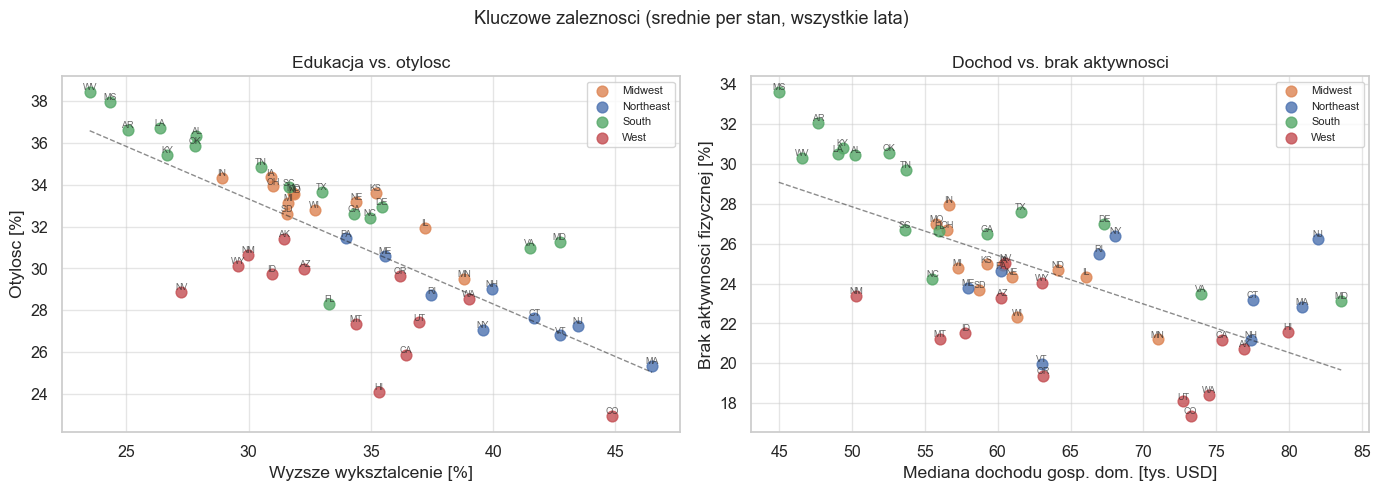

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# edukacja vs otylosc
ax = axes[0]
for region, grp in df_state.groupby("Region"):
    ax.scatter(
        grp["pct_wyksztalcenie_wyzsze"],
        grp["Obesity"],
        label=region,
        color=PALETTE[region],
        s=60,
        alpha=0.8,
    )
    for _, row in grp.iterrows():
        ax.annotate(
            row["LocationAbbr"],
            (row["pct_wyksztalcenie_wyzsze"], row["Obesity"]),
            fontsize=6.5,
            ha="center",
            va="bottom",
            alpha=0.7,
        )

m, b = np.polyfit(df_state["pct_wyksztalcenie_wyzsze"], df_state["Obesity"], 1)
x_line = np.linspace(
    df_state["pct_wyksztalcenie_wyzsze"].min(),
    df_state["pct_wyksztalcenie_wyzsze"].max(),
    100,
)
ax.plot(x_line, m * x_line + b, "k--", linewidth=1, alpha=0.5)
ax.set_xlabel("Wyzsze wyksztalcenie [%]")
ax.set_ylabel("Otylosc [%]")
ax.set_title("Edukacja vs. otylosc")
ax.legend(fontsize=8)

# dochod vs brak aktywnosci
ax = axes[1]
for region, grp in df_state.groupby("Region"):
    ax.scatter(
        grp["mediana_dochodu_gosp_dom"] / 1000,
        grp["NoActivity"],
        label=region,
        color=PALETTE[region],
        s=60,
        alpha=0.8,
    )
    for _, row in grp.iterrows():
        ax.annotate(
            row["LocationAbbr"],
            (row["mediana_dochodu_gosp_dom"] / 1000, row["NoActivity"]),
            fontsize=6.5,
            ha="center",
            va="bottom",
            alpha=0.7,
        )

m2, b2 = np.polyfit(
    df_state["mediana_dochodu_gosp_dom"] / 1000, df_state["NoActivity"], 1
)
x_line2 = np.linspace(
    (df_state["mediana_dochodu_gosp_dom"] / 1000).min(),
    (df_state["mediana_dochodu_gosp_dom"] / 1000).max(),
    100,
)
ax.plot(x_line2, m2 * x_line2 + b2, "k--", linewidth=1, alpha=0.5)
ax.set_xlabel("Mediana dochodu gosp. dom. [tys. USD]")
ax.set_ylabel("Brak aktywnosci fizycznej [%]")
ax.set_title("Dochod vs. brak aktywnosci")
ax.legend(fontsize=8)

plt.suptitle("Kluczowe zaleznosci (srednie per stan, wszystkie lata)", fontsize=13)
plt.tight_layout()
plt.show()

Oba wykresy potwierdzaja silne zaleznosci liniowe. Otylosc spada wraz z poziomem wyksztalcenia - stany poludniowe (MS, WV, AL) skupiaja sie w gornym lewym rogu, podczas gdy Massachusetts, Colorado i Connecticut sa po prawej stronie. Analogicznie brak aktywnosci maleje wraz z dochodem, choc region Northeast lekko zaburza ten trend (stany takie jak NJ i NY maja wyzsze dochody, ale mimo to relatywnie duzy odsetek nieaktywnych - prawdopodobnie efekt gestej zabudowy miejskiej).

## 6. PCA

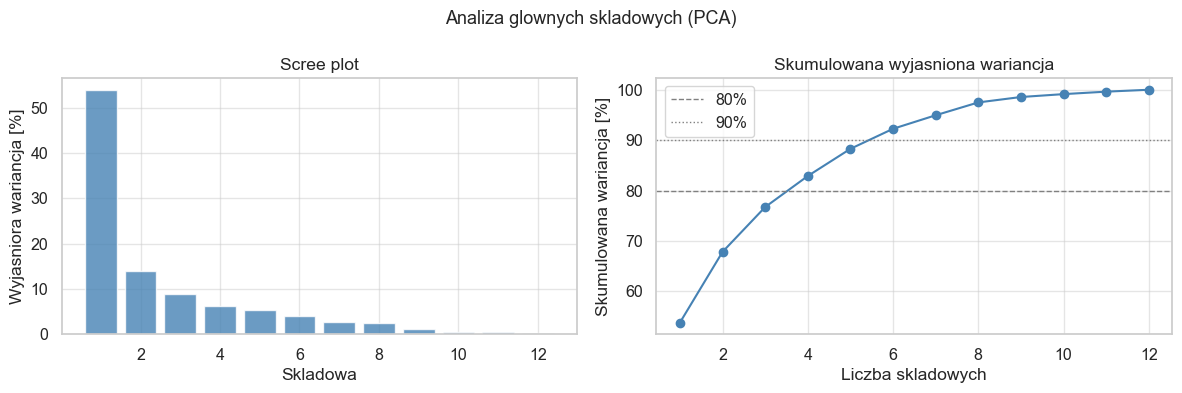

PC1: 53.8%,  PC2: 14.0%,  PC3: 8.9%
PC1+PC2: 67.8%,  PC1+PC2+PC3: 76.7%


In [21]:
X = df_state[CLUSTER_COLS].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(random_state=42)
X_pca = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.bar(range(1, len(explained) + 1), explained * 100, color="steelblue", alpha=0.8)
ax.set_xlabel("Skladowa")
ax.set_ylabel("Wyjasniora wariancja [%]")
ax.set_title("Scree plot")

ax = axes[1]
ax.plot(range(1, len(cumulative) + 1), cumulative * 100, "o-", color="steelblue")
ax.axhline(80, linestyle="--", color="gray", linewidth=1, label="80%")
ax.axhline(90, linestyle=":", color="gray", linewidth=1, label="90%")
ax.set_xlabel("Liczba skladowych")
ax.set_ylabel("Skumulowana wariancja [%]")
ax.set_title("Skumulowana wyjasniona wariancja")
ax.legend()

plt.suptitle("Analiza glownych skladowych (PCA)", fontsize=13)
plt.tight_layout()
plt.show()

print(
    f"PC1: {explained[0]*100:.1f}%,  PC2: {explained[1]*100:.1f}%,  PC3: {explained[2]*100:.1f}%"
)
print(f"PC1+PC2: {cumulative[1]*100:.1f}%,  PC1+PC2+PC3: {cumulative[2]*100:.1f}%")

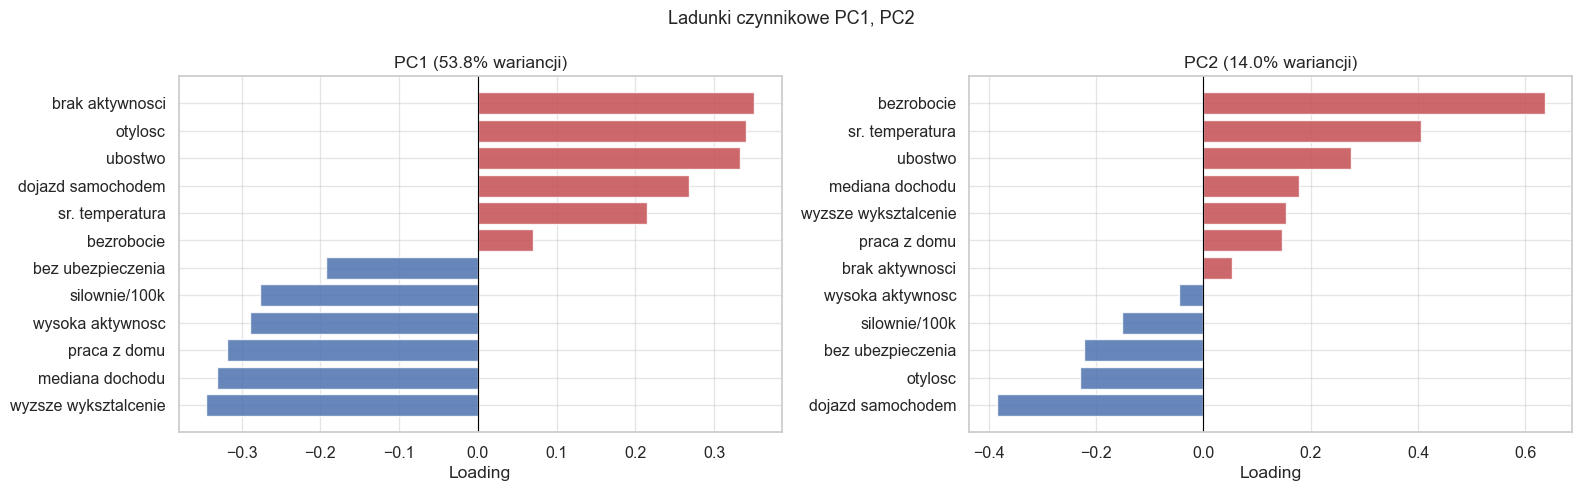

In [22]:
COL_LABELS = {
    "Obesity": "otylosc",
    "NoActivity": "brak aktywnosci",
    "HighActivity": "wysoka aktywnosc",
    "mediana_dochodu_gosp_dom": "mediana dochodu",
    "pct_ubóstwo": "ubostwo",
    "pct_bezrobocie": "bezrobocie",
    "pct_wyksztalcenie_wyzsze": "wyzsze wyksztalcenie",
    "pct_bez_ubezpieczenia": "bez ubezpieczenia",
    "pct_dojazd_samochod": "dojazd samochodem",
    "pct_praca_z_domu": "praca z domu",
    "fitness_per_100k": "silownie/100k",
    "avg_temp": "sr. temperatura",
}

loadings = pd.DataFrame(
    pca.components_[:2].T,
    index=[COL_LABELS[c] for c in CLUSTER_COLS],
    columns=["PC1", "PC2"],
).round(3)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, pc in zip(axes, ["PC1", "PC2"]):
    sorted_load = loadings[pc].sort_values()
    colors = ["#C44E52" if v > 0 else "#4C72B0" for v in sorted_load]
    ax.barh(sorted_load.index, sorted_load.values, color=colors, alpha=0.85)
    ax.axvline(0, color="black", linewidth=0.8)
    idx = int(pc[2]) - 1
    ax.set_title(f"{pc} ({explained[idx]*100:.1f}% wariancji)")
    ax.set_xlabel("Loading")

plt.suptitle("Ladunki czynnikowe PC1, PC2", fontsize=13)
plt.tight_layout()
plt.show()

In [23]:
df_pca = df_state[["LocationDesc", "LocationAbbr", "Region", "Division"]].copy()
df_pca["PC1"] = X_pca[:, 0]
df_pca["PC2"] = X_pca[:, 1]
for col in ["Obesity", "NoActivity", "mediana_dochodu_gosp_dom"]:
    df_pca[col] = df_state[col].values

hover = {
    "LocationDesc": True,
    "Obesity": ":.1f",
    "NoActivity": ":.1f",
    "mediana_dochodu_gosp_dom": ":,.0f",
}

fig1 = px.scatter(
    df_pca,
    x="PC1",
    y="PC2",
    text="LocationAbbr",
    color="Region",
    color_discrete_map=PALETTE,
    hover_data=hover,
    labels={
        "PC1": f"PC1 ({explained[0]*100:.1f}%)",
        "PC2": f"PC2 ({explained[1]*100:.1f}%)",
    },
    title="PCA - PC1 x PC2",
)
fig1.update_traces(textposition="top center", textfont_size=9, marker_size=9)
fig1.update_layout(height=480)
fig1.show()

**PC1 (~57% wariancji)** oś zamożności i zdrowia. Po prawej stronie (wysokie PC1): otyłość, brak aktywności, ubóstwo, dojazdy samochodem — typowy profil południa USA. Po lewej: wysokie wykształcenie, dochód, praca z domu, siłownie — Northeast i wybrzeże zachodnie. To dominująca oś zróżnicowania między stanami.

**PC2 (~14% wariancji)** oś klimatyczno-strukturalna, niezależna od PC1. Wysoko na PC2 plasują się stany z wysokim bezrobociem, ciepłym klimatem i ubóstwem, ale jednocześnie z niskimi dojazdami samochodem i niską otyłością. To brzmi jak Floryda, Arizona — ciepłe stany z dużymi miastami, gdzie ludzie chodzą pieszo, ale bezrobocie i ubóstwo są wysokie.

In [24]:
x = X_pca[:, 0]
y = X_pca[:, 1]

fig = px.scatter(
    x=x,
    y=y,
    hover_name=df_pca.LocationDesc,
    color=df_pca["Region"],
    labels={"x": "PC1", "y": "PC2", "color": "Region"},
    color_discrete_map=PALETTE,
    title="PCA 2D (biplot)",
)


for feature_name, row in loadings.iterrows():
    fig.add_shape(
        type="line",
        x0=0,
        y0=0,
        x1=row["PC1"] * 10,
        y1=row["PC2"] * 10,
        line=dict(color="red", width=1),
    )
    fig.add_annotation(
        x=row["PC1"] * 10.15,
        y=row["PC2"] * 10.15,
        text=feature_name,
        showarrow=False,
        font=dict(size=10),
        xanchor="left",
    )


fig.update_layout(
    autosize=False,
    width=1200,
    height=800,
)

fig.update_traces(marker=dict(size=12), textposition="top center")
fig.show()

### Pre - 7. Nazwy semantyczne dla klastrów

In [53]:
CLUSTER_PALETTE = {
    "Południe - wysokie ryzyko zdrowotne":              "#D32F2F",
    "Południe - umiarkowane ryzyko zdrowotne": "#E65100",
    "Umiarkowany profil, niska temperatura": "#F9A825",
    "Wysoki dobrostan":                      "#1565C0",
    "Najaktywniejsze i najzdrowsze":                      "#2E7D32",
}

CLUSTER_ORDER = list(CLUSTER_PALETTE.keys())

MAP_HIER = {
    1: "Południe - wysokie ryzyko zdrowotne",
    2: "Południe - umiarkowane ryzyko zdrowotne",
    3: "Umiarkowany profil, niska temperatura",
    4: "Wysoki dobrostan",
}

MAP_GMM = {
    0: "Najaktywniejsze i najzdrowsze",
    1: "Umiarkowany profil, niska temperatura",
    2: "Wysoki dobrostan",
    3: "Południe - umiarkowane ryzyko zdrowotne",
    4: "Południe - wysokie ryzyko zdrowotne",
}

MAP_KMEANS = {
    0: "Południe - umiarkowane ryzyko zdrowotne",
    1: "Najaktywniejsze i najzdrowsze",
    2: "Południe - wysokie ryzyko zdrowotne",
    3: "Umiarkowany profil, niska temperatura",
    4: "Wysoki dobrostan",
}

KLASTER_LABELS_HIER = MAP_HIER
KLASTER_LABELS_GMM  = MAP_GMM
KLASTER_LABELS_KM   = MAP_KMEANS


## 7. Klastrowanie hierarchiczne (aglomeracyjne)

In [54]:
COL_LABELS = {
    "Obesity": "otylosc",
    "NoActivity": "brak aktywnosci",
    "HighActivity": "wysoka aktywnosc",
    "mediana_dochodu_gosp_dom": "mediana dochodu",
    "pct_ubóstwo": "ubostwo",
    "pct_bezrobocie": "bezrobocie",
    "pct_wyksztalcenie_wyzsze": "wyzsze wyksztalcenie",
    "pct_bez_ubezpieczenia": "bez ubezpieczenia",
    "pct_dojazd_samochod": "dojazd samochodem",
    "pct_praca_z_domu": "praca z domu",
    "fitness_per_100k": "silownie/100k",
    "avg_temp": "sr. temperatura",
}

# klastrowanie w przestrzeni pierwszych 2 skladowych PCA
X_pca2 = X_pca[:, :2]

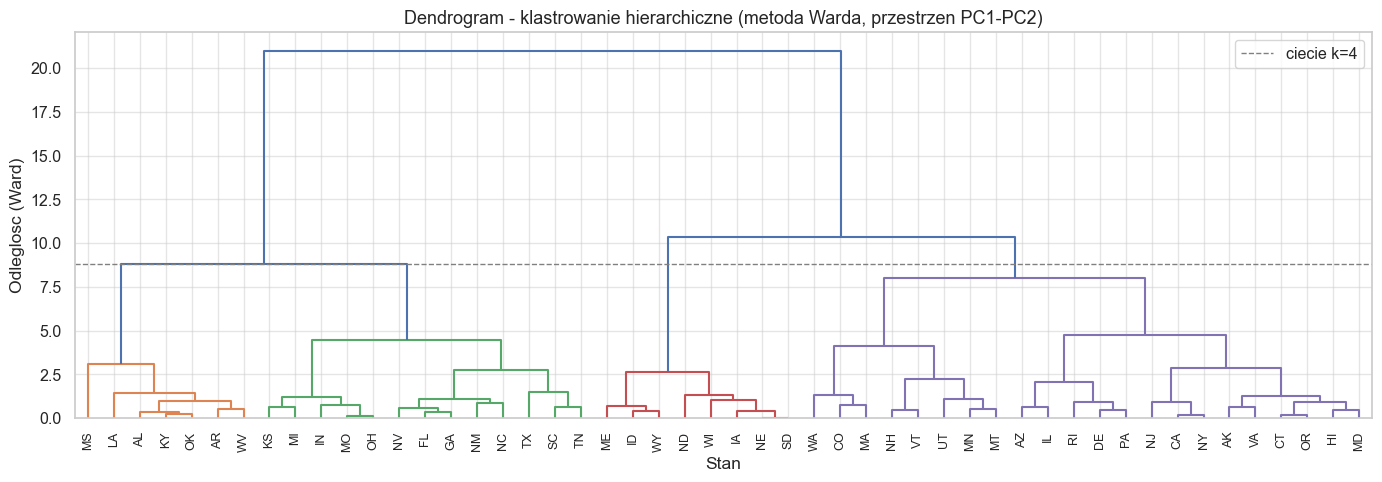

In [55]:
# dendrogram - metoda Warda, przestrzen PC1-PC2
Z = linkage(X_pca2, method="ward")

cut_height = Z[-3, 2]

fig, ax = plt.subplots(figsize=(14, 5))
dendrogram(
    Z,
    labels=df_state["LocationAbbr"].values,
    leaf_rotation=90,
    leaf_font_size=9,
    color_threshold=cut_height,
    ax=ax,
)
ax.set_title(
    "Dendrogram - klastrowanie hierarchiczne (metoda Warda, przestrzen PC1-PC2)",
    fontsize=13,
)
ax.set_xlabel("Stan")
ax.set_ylabel("Odleglosc (Ward)")
ax.axhline(y=cut_height, linestyle="--", color="gray", linewidth=1, label="ciecie k=4")
ax.legend()
plt.tight_layout()
plt.show()

In [56]:
K_BEST = 4

labels_hier = fcluster(Z, K_BEST, criterion="maxclust")
df_state["Klaster"] = pd.Series(labels_hier).map(MAP_HIER).values

sil_hier = silhouette_score(X_pca2, labels_hier)
print(f"Silhouette score (k={K_BEST}, Ward, przestrzen PCA): {sil_hier:.3f}")
print()
print("Rozklad klastrow:")
print(df_state["Klaster"].value_counts().sort_index())


Silhouette score (k=4, Ward, przestrzen PCA): 0.396

Rozklad klastrow:
Klaster
Południe - umiarkowane ryzyko zdrowotne    13
Południe - wysokie ryzyko zdrowotne         7
Umiarkowany profil, niska temperatura       8
Wysoki dobrostan                           22
Name: count, dtype: int64


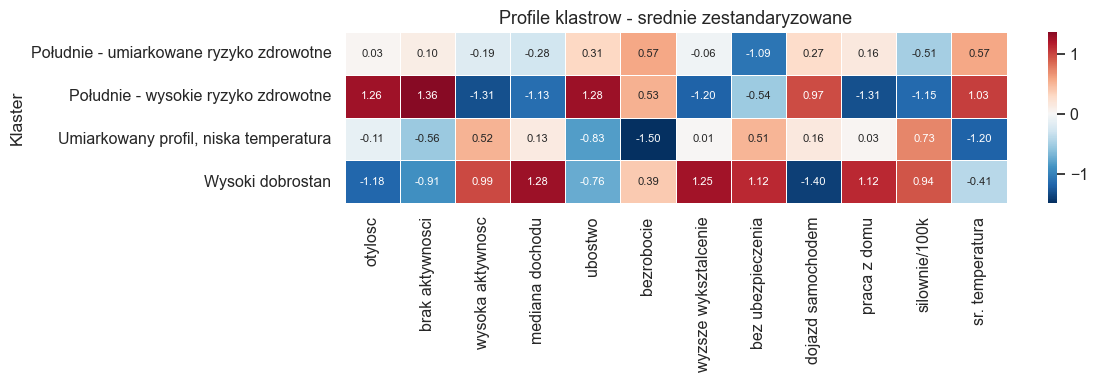

In [57]:
centers = (
    df_state.groupby("Klaster")[CLUSTER_COLS]
    .mean()
    .apply(lambda col: (col - col.mean()) / col.std())
)
centers.columns = [COL_LABELS[c] for c in CLUSTER_COLS]

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(
    centers,
    cmap="RdBu_r",
    center=0,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 8},
    linewidths=0.4,
    ax=ax,
)
ax.set_title("Profile klastrow - srednie zestandaryzowane", fontsize=13)
ax.set_ylabel("Klaster")
plt.tight_layout()
plt.show()

In [58]:
df_pca["Klaster"] = df_state["Klaster"].values

fig1 = px.scatter(
    df_pca,
    x="PC1",
    y="PC2",
    text="LocationAbbr",
    color="Klaster",
    color_discrete_map=CLUSTER_PALETTE,
    symbol="Region",
    hover_data={"LocationDesc": True, "Obesity": ":.1f", "NoActivity": ":.1f"},
    labels={
        "PC1": f"PC1 ({explained[0]*100:.1f}%)",
        "PC2": f"PC2 ({explained[1]*100:.1f}%)",
    },
    title="Klastry hierarchiczne - PC1 x PC2",
)
fig1.update_traces(textposition="top center", textfont_size=9, marker_size=9)
fig1.update_layout(height=480)
fig1.show()

In [59]:
for k in sorted(df_state["Klaster"].unique()):
    stany = df_state[df_state["Klaster"] == k]["LocationAbbr"].tolist()
    print(f"Klaster {k}: {stany}")

Klaster Południe - umiarkowane ryzyko zdrowotne: ['FL', 'GA', 'IN', 'KS', 'MI', 'MO', 'NV', 'NM', 'NC', 'OH', 'SC', 'TN', 'TX']
Klaster Południe - wysokie ryzyko zdrowotne: ['AL', 'AR', 'KY', 'LA', 'MS', 'OK', 'WV']
Klaster Umiarkowany profil, niska temperatura: ['ID', 'IA', 'ME', 'NE', 'ND', 'SD', 'WI', 'WY']
Klaster Wysoki dobrostan: ['AK', 'AZ', 'CA', 'CO', 'CT', 'DE', 'HI', 'IL', 'MD', 'MA', 'MN', 'MT', 'NH', 'NJ', 'NY', 'OR', 'PA', 'RI', 'UT', 'VT', 'VA', 'WA']


C:\Users\Wojciech\AppData\Local\Temp\ipykernel_25336\2223407095.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=9)
C:\Users\Wojciech\AppData\Local\Temp\ipykernel_25336\2223407095.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, fontsize=9)
C:\Users\Wojciech\AppData\Local\Temp\ipykernel_25336\2223407095.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=9)
C:\Users\Wojciech\AppData\Local\Temp\ipykernel_25336\2223407095.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  a

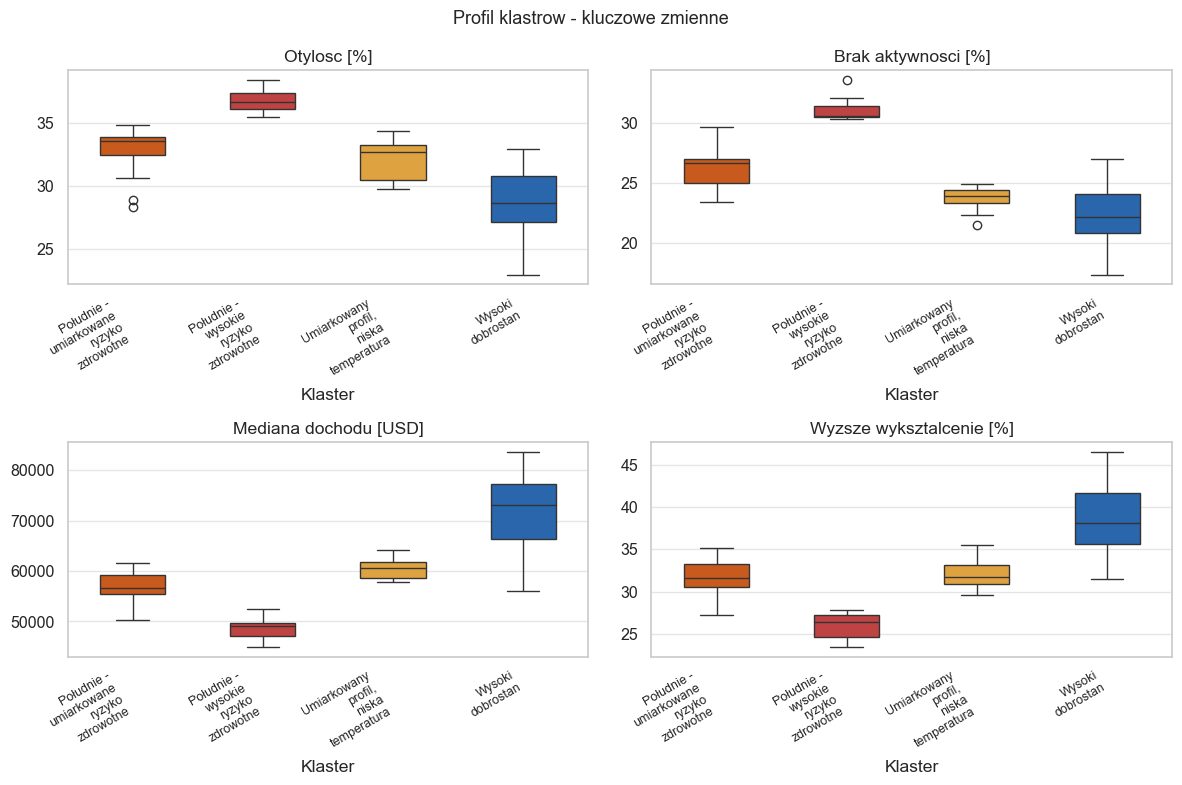

In [60]:
import textwrap



BOX_VARS = [
    ("Obesity", "Otylosc [%]"),
    ("NoActivity", "Brak aktywnosci [%]"),
    ("mediana_dochodu_gosp_dom", "Mediana dochodu [USD]"),
    ("pct_wyksztalcenie_wyzsze", "Wyzsze wyksztalcenie [%]"),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, (col, label) in zip(axes, BOX_VARS):
    sns.boxplot(
        data=df_state,
        x="Klaster",
        y=col,
        palette=CLUSTER_PALETTE,
        order=sorted(df_state["Klaster"].unique()),
        width=0.5,
        ax=ax,
    )
    ax.set_title(label)
    ax.set_xlabel("Klaster")
    ax.set_ylabel("")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=9)
    labels = [textwrap.fill(t.get_text(), width=12) for t in ax.get_xticklabels()]
    ax.set_xticklabels(labels, fontsize=9)

plt.suptitle("Profil klastrow - kluczowe zmienne", fontsize=13)
plt.tight_layout()
plt.show()

In [61]:
fig = px.choropleth(
    df_state,
    locations="LocationAbbr",
    locationmode="USA-states",
    color="Klaster",
    color_discrete_map=CLUSTER_PALETTE,
    category_orders={"Klaster": CLUSTER_ORDER},
    scope="usa",
    hover_name="LocationDesc",
    hover_data={
        "Obesity": ":.1f",
        "NoActivity": ":.1f",
        "mediana_dochodu_gosp_dom": ":,.0f",
    },
    title="Klastry hierarchiczne - mapa USA",
)
fig.update_layout(height=500)


# disable zoom controls and scroll zoom
config = {
    "scrollZoom": False,
    "modeBarButtonsToRemove": [
        "zoom2d",
        "zoomIn2d",
        "zoomOut2d",
        "autoScale2d",
        "resetScale2d",
    ],
}

fig.show(config=config)
fig.write_image("plots/map_hier.png")


Metoda Warda minimalizuje wariancje wewnatrzklastrow. Dendrogram ujawnia dodatkowa informacje niedostepna w K-Means - mozna odczytac, ktore stany sa do siebie najbardziej podobne (laczą sie na niskiej wysokosci) i ktore sa outlierami w swoim klastrze (dolaczaja pozno, na duzej wysokosci).

Interpretacja klastrow nie pokrywa sie idealnie z wynikami K-Means - klastry są mniej posortowane geograficznie.

## 8. Klastrowanie GMM (Gaussian Mixture Model)

In [62]:
from sklearn.mixture import GaussianMixture

for n in range(2, 8):
    gmm = GaussianMixture(n_components=n, covariance_type="full", random_state=42)
    labels = gmm.fit_predict(X_pca2)
    score = silhouette_score(X_pca2, labels)
    print(n, f"{score:.3f}")

2 0.431
3 0.277
4 0.343
5 0.419
6 0.334
7 0.410


In [63]:
cov_types = ["full", "tied", "diag", "spherical"]

for cov in cov_types:
    gmm = GaussianMixture(n_components=5, covariance_type=cov, random_state=42)
    labels = gmm.fit_predict(X_pca2)
    score = silhouette_score(X_pca2, labels)
    print(cov, f"{score:.3f}")

full 0.419
tied 0.426
diag 0.405
spherical 0.415


In [64]:
gmm = GaussianMixture(n_components=5, covariance_type="tied", random_state=42)
gmm_labels = gmm.fit_predict(X_pca2)

df_state["Klaster_GMM"] = pd.Series(gmm_labels).map(MAP_GMM).values

sil_gmm = silhouette_score(X_pca2, gmm_labels)
print(f"Silhouette score (GMM, k=5, przestrzen PCA): {sil_gmm:.3f}")
print("\nRozklad klastrow GMM:")
print(df_state["Klaster_GMM"].value_counts().sort_index())


Silhouette score (GMM, k=5, przestrzen PCA): 0.426

Rozklad klastrow GMM:
Klaster_GMM
Najaktywniejsze i najzdrowsze               8
Południe - umiarkowane ryzyko zdrowotne    13
Południe - wysokie ryzyko zdrowotne         7
Umiarkowany profil, niska temperatura      11
Wysoki dobrostan                           11
Name: count, dtype: int64


In [65]:
df_pca["Klaster_GMM"] = df_state["Klaster_GMM"].values

fig_gmm = px.scatter(
    df_pca,
    x="PC1",
    y="PC2",
    text="LocationAbbr",
    color="Klaster_GMM",
    color_discrete_map=CLUSTER_PALETTE,
    category_orders={"Klaster_GMM": CLUSTER_ORDER},
    hover_data=["LocationDesc", "Obesity", "NoActivity", "Region"],
    title="Klastrowanie GMM (k=4) w przestrzeni PCA",
    height=600,
)
fig_gmm.update_traces(
    textposition="top center", selector=dict(mode="markers+text"), marker=dict(size=12)
)
fig_gmm.add_hline(y=0, line_width=0.5, line_color="lightgray")
fig_gmm.add_vline(x=0, line_width=0.5, line_color="lightgray")

fig_gmm.show()

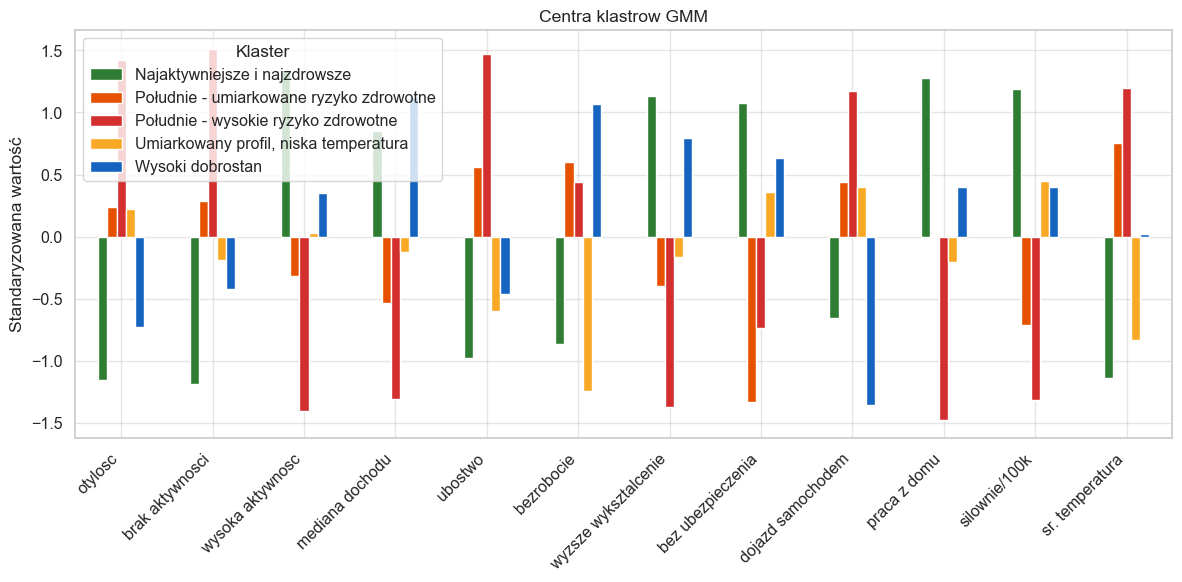

In [66]:
centers_gmm = (
    df_state.groupby("Klaster_GMM")[CLUSTER_COLS]
    .mean()
    .apply(lambda col: (col - col.mean()) / col.std())
)
centers_gmm.columns = [COL_LABELS[c] for c in CLUSTER_COLS]

fig, ax = plt.subplots(figsize=(12, 6))
centers_gmm.T.plot(
    kind="bar", ax=ax, color=[CLUSTER_PALETTE[c] for c in centers_gmm.index]
)
ax.set_title("Centra klastrow GMM")
ax.set_ylabel("Standaryzowana wartość")
ax.legend(title="Klaster")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [67]:

fig = px.choropleth(
    df_state,
    locations="LocationAbbr",
    locationmode="USA-states",
    color="Klaster_GMM",
    color_discrete_map=CLUSTER_PALETTE,
    category_orders={"Klaster_GMM": CLUSTER_ORDER},
    scope="usa",
    hover_name="LocationDesc",
    hover_data={
        "Obesity": ":.1f",
        "NoActivity": ":.1f",
        "mediana_dochodu_gosp_dom": ":,.0f",
    },
    title="Klastry GMM - mapa USA",
)
fig.update_layout(height=500)
fig.show(config=config)

fig.write_image("plots/map_gmm.png")


## 9. K-Means

In [68]:
from sklearn.cluster import KMeans

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_pca2)
    score = silhouette_score(X_pca2, labels)
    print(k, f"{score:.3f}")

2 0.442
3 0.386
4 0.414
5 0.425
6 0.432
7 0.442
8 0.440
9 0.427
10 0.430


In [69]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_pca2)

df_state["Klaster_KMeans"] = pd.Series(kmeans_labels).map(MAP_KMEANS).values

sil_km = silhouette_score(X_pca2, kmeans_labels)
print(f"Silhouette score (KMeans, k=5, przestrzen PCA): {sil_km:.3f}")
print("\nRozklad klastrow KMeans:")
print(df_state["Klaster_KMeans"].value_counts().sort_index())


Silhouette score (KMeans, k=5, przestrzen PCA): 0.425

Rozklad klastrow KMeans:
Klaster_KMeans
Najaktywniejsze i najzdrowsze               8
Południe - umiarkowane ryzyko zdrowotne    14
Południe - wysokie ryzyko zdrowotne         7
Umiarkowany profil, niska temperatura      10
Wysoki dobrostan                           11
Name: count, dtype: int64


In [70]:
df_pca["Klaster_KMeans"] = df_state["Klaster_KMeans"].values

fig_km = px.scatter(
    df_pca,
    x="PC1",
    y="PC2",
    text="LocationAbbr",
    color="Klaster_KMeans",
    color_discrete_map=CLUSTER_PALETTE,
    category_orders={"Klaster_KMeans": CLUSTER_ORDER},
    hover_data=["LocationDesc", "Obesity", "NoActivity", "Region"],
    title="Klastrowanie KMeans (k=4) w przestrzeni PCA",
    height=600,
)

fig_km.update_traces(textposition="top center", selector=dict(mode="markers+text"))
fig_km.add_hline(y=0, line_width=0.5, line_color="lightgray")
fig_km.add_vline(x=0, line_width=0.5, line_color="lightgray")

fig_km.show()

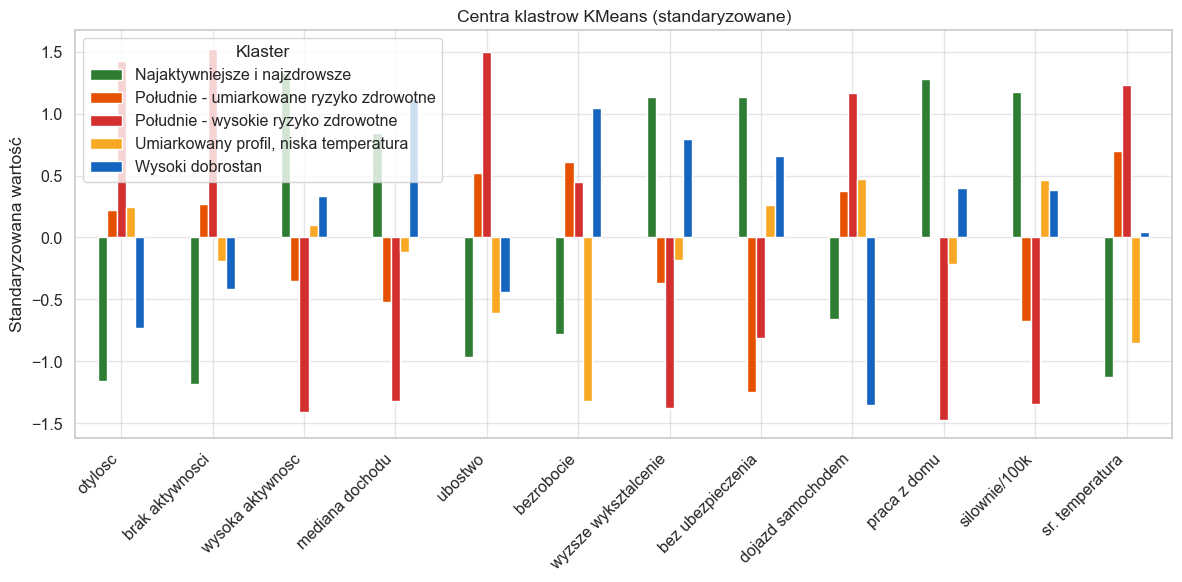

In [71]:
centers_km = (
    df_state.groupby("Klaster_KMeans")[CLUSTER_COLS]
    .mean()
    .apply(lambda col: (col - col.mean()) / col.std())
)

centers_km.columns = [COL_LABELS[c] for c in CLUSTER_COLS]

fig, ax = plt.subplots(figsize=(12, 6))
centers_km.T.plot(
    kind="bar", ax=ax, color=[CLUSTER_PALETTE[c] for c in centers_km.index]
)

ax.set_title("Centra klastrow KMeans (standaryzowane)")
ax.set_ylabel("Standaryzowana wartość")
ax.legend(title="Klaster")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [72]:
fig = px.choropleth(
    df_state,
    locations="LocationAbbr",
    locationmode="USA-states",
    color="Klaster_KMeans",
    color_discrete_map=CLUSTER_PALETTE,
    category_orders={"Klaster_KMeans": CLUSTER_ORDER},
    scope="usa",
    hover_name="LocationDesc",
    hover_data={
        "Obesity": ":.1f",
        "NoActivity": ":.1f",
        "mediana_dochodu_gosp_dom": ":,.0f",
    },
    title="Klastry K-Means - mapa USA",
)
fig.update_layout(height=500)
fig.show(config=config)

fig.write_image("plots/map_kmeans.png")


## 10. Porównanie

In [74]:
print("\nAktualne wyniki silhouette score:")
print(f"KMeans: {sil_km:.3f}")
print(f"GMM: {sil_gmm:.3f}")
print(f"Hierarchical: {sil_hier:.3f}")


Aktualne wyniki silhouette score:
KMeans: 0.425
GMM: 0.426
Hierarchical: 0.396


In [75]:
from sklearn.metrics import davies_bouldin_score

dbs_kmeans = davies_bouldin_score(X_pca2, kmeans_labels)
dbs_gmm = davies_bouldin_score(X_pca2, gmm_labels)
dbs_hier = davies_bouldin_score(X_pca2, labels_hier)

print("\nAktualne wyniki Davies-Bouldin score:")
print(f"KMeans: {dbs_kmeans:.3f}")
print(f"GMM: {dbs_gmm:.3f}")
print(f"Hierarchical: {dbs_hier:.3f}")


Aktualne wyniki Davies-Bouldin score:
KMeans: 0.781
GMM: 0.792
Hierarchical: 0.726


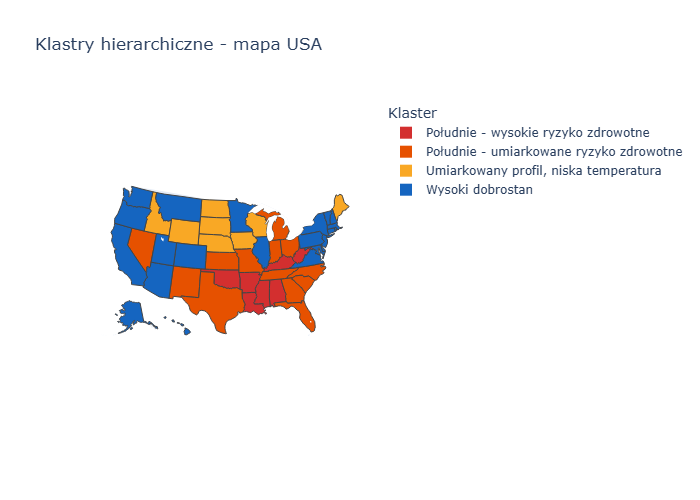

In [76]:
from IPython.display import Image

Image(filename="plots/map_hier.png")

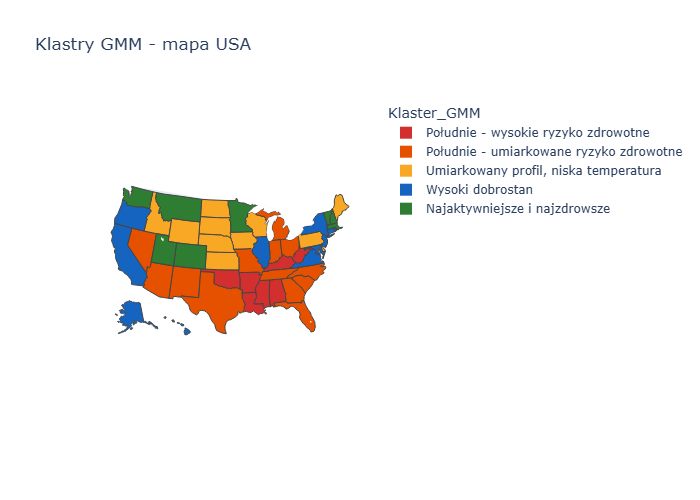

In [77]:
Image(filename="plots/map_gmm.png")

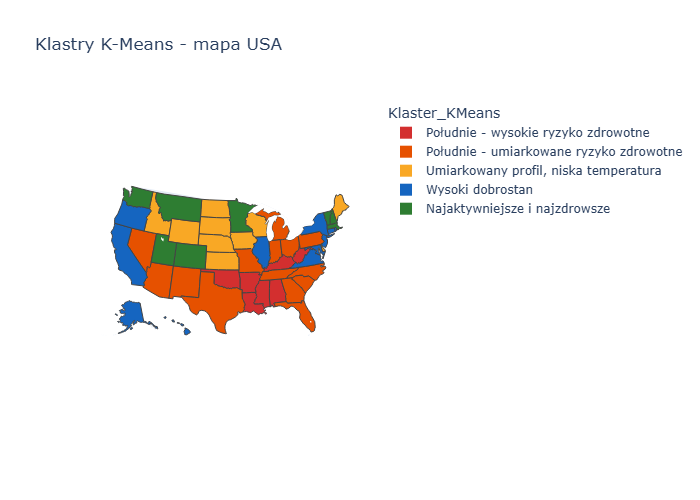

In [78]:
Image(filename="plots/map_kmeans.png")

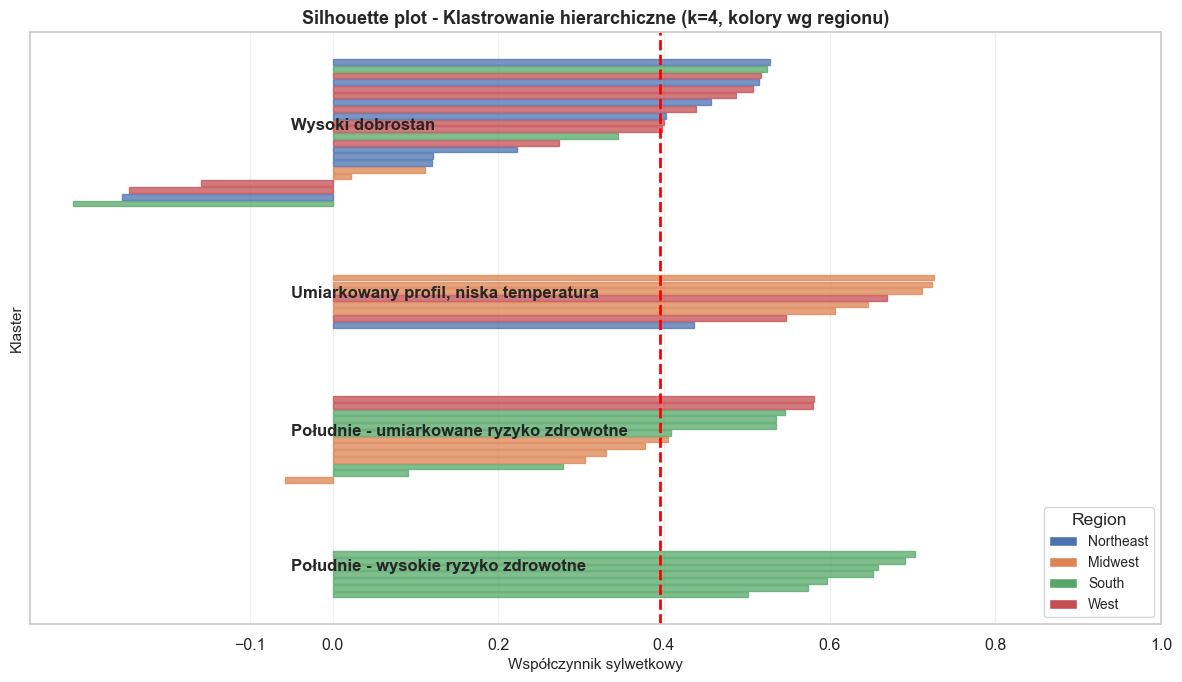

In [81]:
from sklearn.metrics import silhouette_samples
from matplotlib.patches import Patch

sample_silhouette_values = silhouette_samples(X_pca2, labels_hier)

fig, ax = plt.subplots(figsize=(12, 7))

clust_hier = sorted(np.unique(labels_hier))
y_lower = 10

for c in clust_hier:
    # Get mask for states in this cluster
    cluster_mask = labels_hier == c

    # Get indices and silhouette values for this cluster
    cluster_sil_values = sample_silhouette_values[cluster_mask]
    cluster_indices = np.where(cluster_mask)[0]

    # Sort by silhouette value
    sorted_positions = np.argsort(cluster_sil_values)

    size_cluster_i = len(cluster_indices)
    y_upper = y_lower + size_cluster_i

    # Draw bar for each state
    for i in range(size_cluster_i):
        # Get the state index in original data
        state_idx = cluster_indices[sorted_positions[i]]

        # Get region and silhouette value
        region = df_state.iloc[state_idx]["Region"]
        color = PALETTE[region]
        sil_val = cluster_sil_values[sorted_positions[i]]

        # Draw horizontal bar
        y_pos = y_lower + i
        ax.barh(
            y_pos,
            sil_val,
            height=0.85,
            left=0,
            facecolor=color,
            edgecolor=color,
            alpha=0.75,
        )

    # Label cluster
    cluster_label = MAP_HIER[c]
    ax.text(
        -0.05,
        y_lower + 0.5 * size_cluster_i,
        cluster_label,
        fontsize=12,
        fontweight="bold",
    )

    y_lower = y_upper + 10

ax.set_title(
    "Silhouette plot - Klastrowanie hierarchiczne (k=4, kolory wg regionu)",
    fontsize=13,
    fontweight="bold",
)
ax.set_xlabel("Współczynnik sylwetkowy", fontsize=11)
ax.set_ylabel("Klaster", fontsize=11)

ax.axvline(
    x=sil_hier,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Średni wynik: {sil_hier:.3f}",
)

ax.set_yticks([])
ax.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1.0])

# Add legend for regions
legend_elements = [
    Patch(facecolor=PALETTE[region], label=region)
    for region in ["Northeast", "Midwest", "South", "West"]
]
ax.legend(handles=legend_elements, fontsize=10, loc="lower right", title="Region")

ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

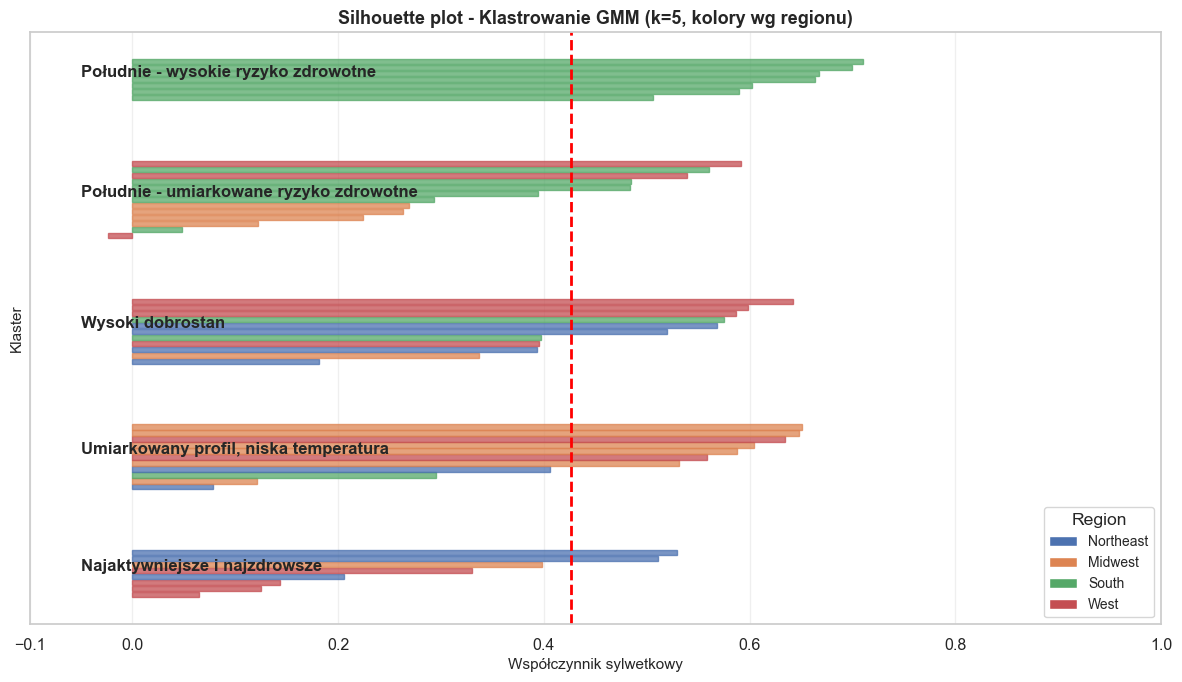

In [80]:
from sklearn.metrics import silhouette_samples
from matplotlib.patches import Patch

sample_silhouette_values = silhouette_samples(X_pca2, gmm_labels)

fig, ax = plt.subplots(figsize=(12, 7))

clust_gmm = sorted(np.unique(gmm_labels))
y_lower = 10

for c in clust_gmm:
    # Get mask for states in this cluster
    cluster_mask = gmm_labels == c

    # Get indices and silhouette values for this cluster
    cluster_sil_values = sample_silhouette_values[cluster_mask]
    cluster_indices = np.where(cluster_mask)[0]

    # Sort by silhouette value
    sorted_positions = np.argsort(cluster_sil_values)

    size_cluster_i = len(cluster_indices)
    y_upper = y_lower + size_cluster_i

    # Draw bar for each state
    for i in range(size_cluster_i):
        # Get the state index in original data
        state_idx = cluster_indices[sorted_positions[i]]

        # Get region and silhouette value
        region = df_state.iloc[state_idx]["Region"]
        color = PALETTE[region]
        sil_val = cluster_sil_values[sorted_positions[i]]

        # Draw horizontal bar
        y_pos = y_lower + i
        ax.barh(
            y_pos,
            sil_val,
            height=0.85,
            left=0,
            facecolor=color,
            edgecolor=color,
            alpha=0.75,
        )

    # Label cluster
    cluster_label = MAP_GMM[c]
    ax.text(
        -0.05,
        y_lower + 0.5 * size_cluster_i,
        cluster_label,
        fontsize=12,
        fontweight="bold",
    )

    y_lower = y_upper + 10

ax.set_title(
    "Silhouette plot - Klastrowanie GMM (k=5, kolory wg regionu)",
    fontsize=13,
    fontweight="bold",
)
ax.set_xlabel("Współczynnik sylwetkowy", fontsize=11)
ax.set_ylabel("Klaster", fontsize=11)

ax.axvline(
    x=sil_gmm,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Średni wynik: {sil_gmm:.3f}",
)

ax.set_yticks([])
ax.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1.0])

# Add legend for regions
legend_elements = [
    Patch(facecolor=PALETTE[region], label=region)
    for region in ["Northeast", "Midwest", "South", "West"]
]
ax.legend(handles=legend_elements, fontsize=10, loc="lower right", title="Region")

ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

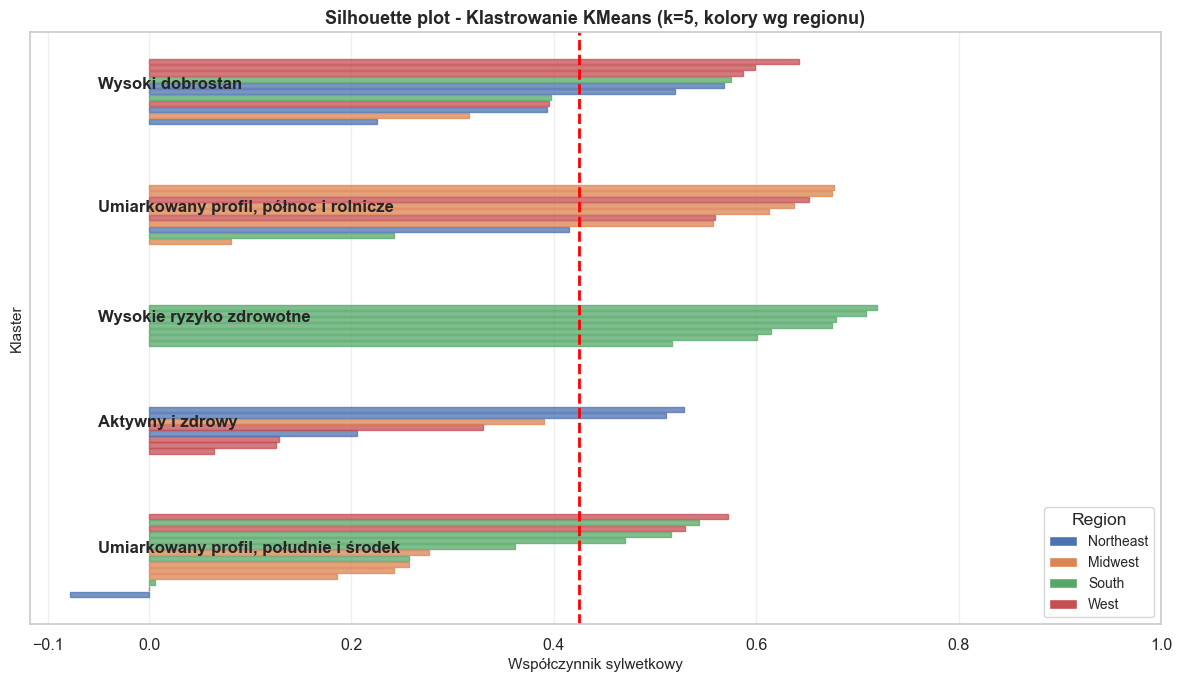

In [52]:
from sklearn.metrics import silhouette_samples
from matplotlib.patches import Patch

sample_silhouette_values = silhouette_samples(X_pca2, kmeans_labels)

fig, ax = plt.subplots(figsize=(12, 7))

clust_km = sorted(np.unique(kmeans_labels))
y_lower = 10

for c in clust_km:
    # Get mask for states in this cluster
    cluster_mask = kmeans_labels == c

    # Get indices and silhouette values for this cluster
    cluster_sil_values = sample_silhouette_values[cluster_mask]
    cluster_indices = np.where(cluster_mask)[0]

    # Sort by silhouette value
    sorted_positions = np.argsort(cluster_sil_values)

    size_cluster_i = len(cluster_indices)
    y_upper = y_lower + size_cluster_i

    # Draw bar for each state
    for i in range(size_cluster_i):
        # Get the state index in original data
        state_idx = cluster_indices[sorted_positions[i]]

        # Get region and silhouette value
        region = df_state.iloc[state_idx]["Region"]
        color = PALETTE[region]
        sil_val = cluster_sil_values[sorted_positions[i]]

        # Draw horizontal bar
        y_pos = y_lower + i
        ax.barh(
            y_pos,
            sil_val,
            height=0.85,
            left=0,
            facecolor=color,
            edgecolor=color,
            alpha=0.75,
        )

    # Label cluster
    cluster_label = MAP_KMEANS[c]
    ax.text(
        -0.05,
        y_lower + 0.5 * size_cluster_i,
        cluster_label,
        fontsize=12,
        fontweight="bold",
    )

    y_lower = y_upper + 10

ax.set_title(
    "Silhouette plot - Klastrowanie KMeans (k=5, kolory wg regionu)",
    fontsize=13,
    fontweight="bold",
)
ax.set_xlabel("Współczynnik sylwetkowy", fontsize=11)
ax.set_ylabel("Klaster", fontsize=11)

ax.axvline(
    x=sil_km,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Średni wynik: {sil_km:.3f}",
)

ax.set_yticks([])
ax.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1.0])

# Add legend for regions
legend_elements = [
    Patch(facecolor=PALETTE[region], label=region)
    for region in ["Northeast", "Midwest", "South", "West"]
]
ax.legend(handles=legend_elements, fontsize=10, loc="lower right", title="Region")

ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()